The goal of this task is to predict whether an individual earns more than $50,000 a year (>50K) based on census data (age, education, occupation, etc.).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the Adult Income dataset from OpenML
adult = fetch_openml(data_id=1590, as_frame=True, parser='auto')
df_adult = adult.frame

print(f"Data Shape (Rows, Columns): {df_adult.shape}\n")
display(df_adult.head())

Data Shape (Rows, Columns): (48842, 15)



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


Data Cleaning & Exploratory Data Analysis (EDA)

In [14]:
# Check for missing values
print( df_adult.info())

print()
print('statistical summary:')
print(df_adult.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB
None

statistical summary:
                age        fnlw

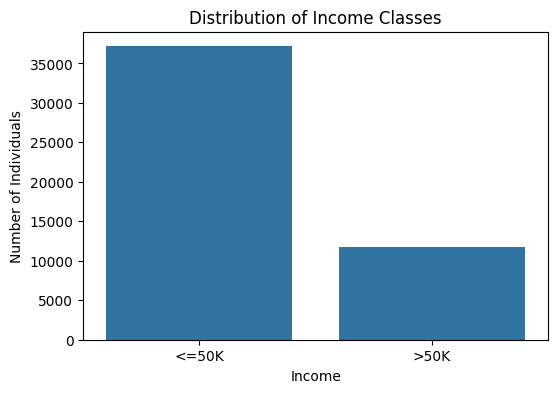

In [4]:


# Visualize the Target Variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_adult)
plt.title('Distribution of Income Classes')
plt.xlabel('Income')
plt.ylabel('Number of Individuals')
plt.show()

Key Insights from EDA

*   Mixed Data Types: The dataset contains 48,842 rows and 15 columns. It is heavily mixed, containing 6 numerical features (int64) and 9 categorical features (category).
*   The .info() output confirms exactly where our missing data lives. Out of 48,842 total rows, workclass (46,043), occupation (46,033), and native-country (47,985) are the only columns missing values.
* statistical summary shows the average individual in this dataset is ~38.6 years old and works a standard 40-hour workweek (both the mean and median for hours-per-week sit right around 40).
* Class Imbalance: The target variable is highly imbalanced. The vast majority of individuals in this dataset earn <=50K.



Model Training & Evaluation

In [17]:
# 1. Define Features (X) and Target (y)
X = df_adult.drop('class', axis=1)
# Convert the target into explicit 0s and 1s (1 if >50K, else 0)
y = df_adult['class'].apply(lambda val: 1 if val == '>50K' else 0)

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [18]:

# 3. Identify which columns are numbers and which are text (categories)
# Select numerical columns
num_features = X.select_dtypes(include=['int64', 'float64']).columns
# Select categorical columns
cat_features = X.select_dtypes(include=['category', 'object']).columns

# 4. Build the separate conveyor belts (Transformers)
# Numerical Belt: Impute missing -> Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Belt: Impute missing -> One-Hot Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Combine the belts into one master preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 6. Build the Final Master Pipeline (Preprocessor + Model)
adult_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 7. Train the entire system with one line of code!
adult_pipeline.fit(X_train, y_train)

# 8. Make predictions
adult_preds = adult_pipeline.predict(X_test)

# 9. Evaluate
accuracy = accuracy_score(y_test, adult_preds)
print("--- Adult Income Pipeline Results ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, adult_preds))

--- Adult Income Pipeline Results ---
Accuracy: 85.65%

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      7479
           1       0.74      0.60      0.66      2290

    accuracy                           0.86      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769

